In [33]:
import os
import json
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
DATASET_ROOT = "../dataset/splitted_coco_dataset"

test_ds = COCODataset(
    f"{DATASET_ROOT}/test/images",
    f"{DATASET_ROOT}/test/annotations.json"
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
    )

In [35]:
NUM_CLASSES = 22 + 1  # +1 bg

# model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# load
MODEL_PATH = "fasterrcnn_model.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [36]:
def evaluate_test_set(model, dataset, ann_file, device, score_threshold=0.5):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

    coco_gt = COCO(ann_file)

    
    if "info" not in coco_gt.dataset:
        coco_gt.dataset["info"] = {}
    if "licenses" not in coco_gt.dataset:
        coco_gt.dataset["licenses"] = []

    coco_results = []

    # Predictions 
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            image_ids = [t["image_id"].item() for t in targets]

            outputs = model(images)

            for output, img_id in zip(outputs, image_ids):
                boxes = output["boxes"].cpu()
                scores = output["scores"].cpu()
                labels = output["labels"].cpu()

                for box, score, label in zip(boxes, scores, labels):
                    if score < score_threshold:
                        continue
                    x1, y1, x2, y2 = box.tolist()
                    coco_results.append({
                        "image_id": img_id,
                        "category_id": int(label)-1,
                        "bbox": [x1, y1, x2-x1, y2-y1],
                        "score": float(score)
                    })

    # Algemeen COCO evaluatie
    coco_dt = coco_gt.loadRes(coco_results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    
    print("\n=== ALGEMENE SCORES ===")
    coco_eval.summarize()

    # Per-class AP
    print("\n=== PER CLASS AP ===")
    cat_ids = coco_gt.getCatIds()
    cat_info = {c['id']: c['name'] for c in coco_gt.loadCats(cat_ids)}

    for catId in cat_ids:
        coco_eval.params.catIds = [catId]
        coco_eval.evaluate()
        coco_eval.accumulate()
        print(f"\nClass {catId} ({cat_info[catId]}):")
        coco_eval.summarize()


In [37]:
evaluate_test_set(
    model,
    test_ds,
    f"{DATASET_ROOT}/test/annotations.json",
    device
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.33s).
Accumulating evaluation results...
DONE (t=0.13s).

=== ALGEMENE SCORES ===
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.378
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.447
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.247
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.362
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.447
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.458
 Average Recall     (AR) @[ IoU=0.50:0.

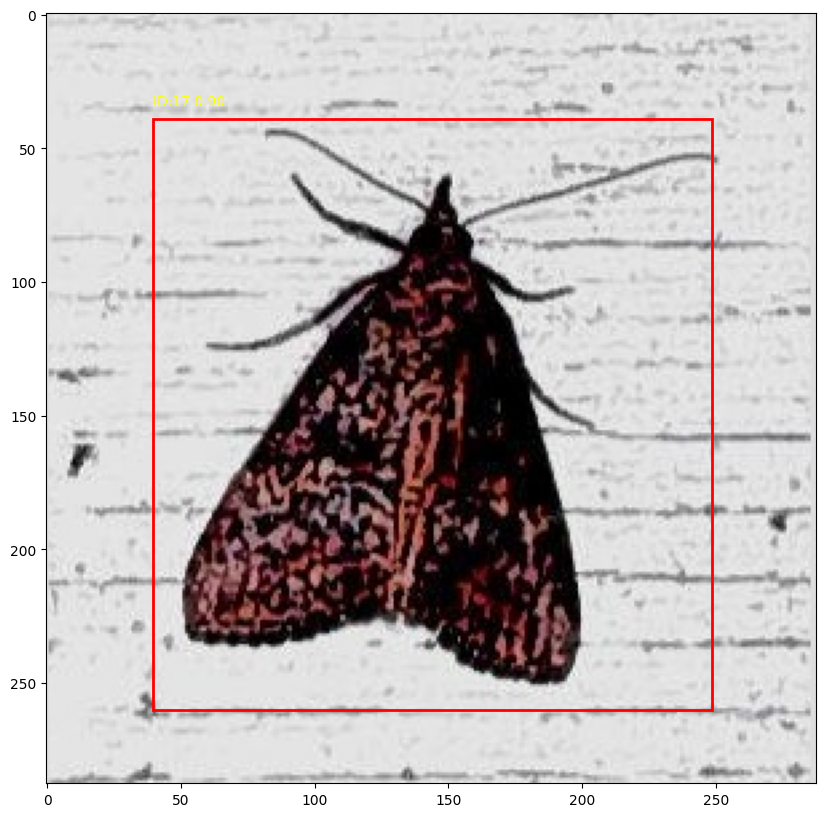

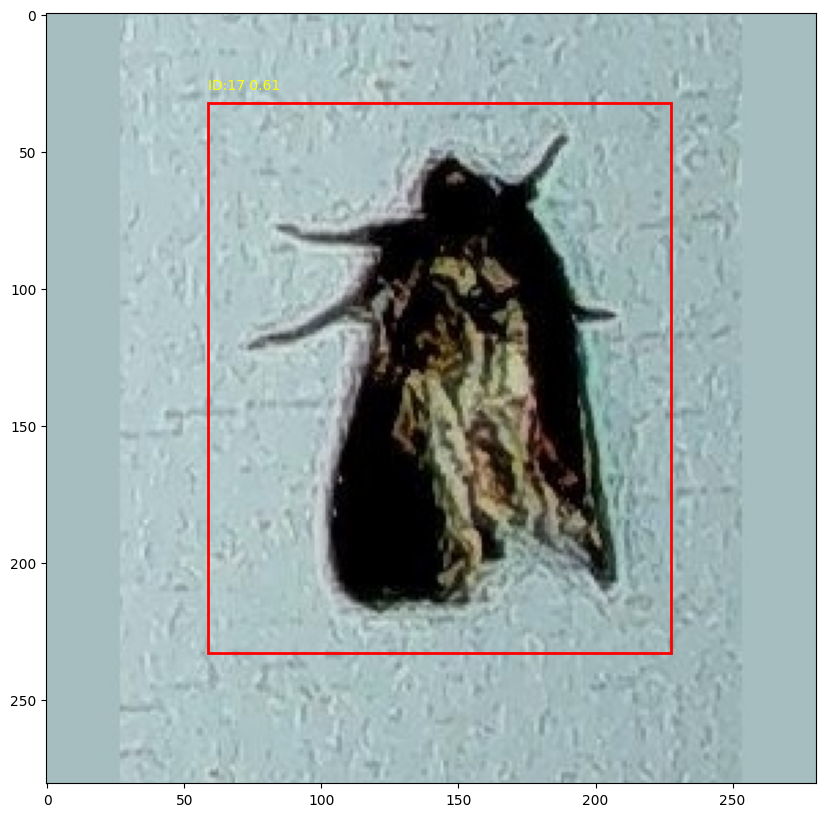

In [38]:

def visualize_prediction(model, dataset, idx=0, threshold=0.5):
    model.eval()
    img, target = dataset[idx]
    with torch.no_grad():
        pred = model([img.to(device)])[0]

    img_np = img.permute(1,2,0).cpu().numpy()

    fig, ax = plt.subplots(1,1, figsize=(10,10))
    ax.imshow(img_np)

    # draw predictions
    for box, score, label in zip(pred["boxes"], pred["scores"], pred["labels"]):
        if score > threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"ID:{label.item()} {score:.2f}", color='yellow', fontsize=10)

    plt.show()


visualize_prediction(model, test_ds, idx=0, threshold=0.5)
visualize_prediction(model, test_ds, idx=6, threshold=0.5)
